# <b><font color='saddlebrown'>Центральная предельная теорема</font></b>

In [1]:
# Импорт библиотек
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### <b><font color='saddlebrown'>1. Вероятностное сэмплирование</font></b>

##### <b><font color='saddlebrown'>1.1. Простая случайная выборка</font></b>

In [2]:
# Модуль random
data_height = [175, 180, 165, 166, 181, 177, 169, 159, 164, 179]
sample_random = random.sample(data_height, 3)
print(sample_random)

[159, 179, 169]


In [3]:
# Библиотека Numpy
sample_numpy = np.random.choice(data_height, size = 3, replace = False)
print(sample_numpy)

[177 159 166]


In [4]:
# Библиотека Pandas
df = pd.DataFrame({
    "Имя": ["Анна", "Борис", "Вика", "Глеб", "Дина"],
    "Возраст": [23, 34, 28, 45, 31]
})

# Простая случайная выборка из 2 строк
sample_df = df.sample(n = 2, random_state = 42)
print(sample_df)

     Имя  Возраст
1  Борис       34
4   Дина       31


In [5]:
# С помощью scipy
sample_scipy = stats.norm.rvs(size = 10)
print(sample_scipy)

[ 1.57148004  0.27569909  0.07962089 -0.23869838 -0.1620543   0.96018602
  2.15302171 -0.21966387  0.55130645 -0.16582975]


##### <b><font color='saddlebrown'>1.2. Стратифицированная случайная выборка</font></b>

In [6]:
# Pandas
df = pd.DataFrame({
    "Группа": ["A", "A", "A", "B", "B", "B", "C", "C", "C"],
    "Значение": [10, 12, 15, 20, 25, 22, 30, 28, 32]
})
sample_df = (df.groupby('Группа').sample(n=2))
sample_df

,Группа,Значение
2,A,15
0,A,10
3,B,20
5,B,22
8,C,32
7,C,28


##### <b><font color='saddlebrown'>1.3. Кластерная выборка</font></b>

In [7]:
# Генерация данных
df = pd.DataFrame({
    "Город": np.repeat(["Париж", "Берлин", "Мадрид", "Рим", "Амстердам"], 10),
    "Район": [f"Район {i}" for i in range(1, 51)],
    "Житель_ID": range(1, 51),
    "Доход": np.random.randint(30000, 120000, 50)
})
df.sample(10)

,Город,Район,Житель_ID,Доход
8,Париж,Район 9,9,106362
4,Париж,Район 5,5,35922
44,Амстердам,Район 45,45,30991
11,Берлин,Район 12,12,96024
39,Рим,Район 40,40,63912
28,Мадрид,Район 29,29,37718
48,Амстердам,Район 49,49,70305
46,Амстердам,Район 47,47,101348
21,Мадрид,Район 22,22,108954
0,Париж,Район 1,1,36114


In [8]:
# Уникальные города
clusters = df["Город"].unique()

# Случайно выбираем 2 города
selected_clusters = random.sample(list(clusters), k = 2)
selected_clusters

['Амстердам', 'Мадрид']

In [9]:
cluster_sample = df[df["Город"].isin(selected_clusters)]
cluster_sample

,Город,Район,Житель_ID,Доход
20,Мадрид,Район 21,21,111342
21,Мадрид,Район 22,22,108954
22,Мадрид,Район 23,23,102631
23,Мадрид,Район 24,24,65592
24,Мадрид,Район 25,25,106485
25,Мадрид,Район 26,26,30997
26,Мадрид,Район 27,27,37703
27,Мадрид,Район 28,28,85276
28,Мадрид,Район 29,29,37718
29,Мадрид,Район 30,30,94015


##### <b><font color='saddlebrown'>1.4. Систематическая выборка</font></b>

In [10]:
# Задаём размер выборки
N = len(df)   # общее количество элементов
n = 6         # сколько хотим выбрать
k = N // n    # шаг выборки
print(N, n, k)

50 6 8


In [11]:
# Определяем случайную стартовую позицию
start = random.randint(0, k - 1)
start

1

In [12]:
# Берём каждый k-й элемент, начиная с start
systematic_sample = df.iloc[start:len(df):k]
systematic_sample

,Город,Район,Житель_ID,Доход
1,Париж,Район 2,2,104694
9,Париж,Район 10,10,109868
17,Берлин,Район 18,18,112186
25,Мадрид,Район 26,26,30997
33,Рим,Район 34,34,51145
41,Амстердам,Район 42,42,90041
49,Амстердам,Район 50,50,56374


### <b><font color='saddlebrown'>2. Центральная предельная теорема (ЦПТ)</font></b>

##### <b><font color='saddlebrown'>2.1. Моделирование выборочных распределений</font></b>
Мы будем генерировать случайные выборки из равномерного распределения. Предположим, что наша генеральная совокупность имеет равномерное распределение с a = 10 и b = 100.

In [19]:
# Параметры генеральной совокупностиa 
a = 10
b = 100

In [20]:
# Функция generate_sample_means для генерации случайных выборок и вычисления выборочных средних
# На вход принимает 2 аргумента: sample_size - размер выборки, num_samples - кол-во выборок
# На выходе отдает список выборочных средних
def  generate_sample_means(sample_size, num_samples):
    sample_means = []
    for _ in range(num_samples):
        sample = stats.uniform.rvs(a, b - a, size = sample_size)
        sample_mean = np.mean(sample)
        sample_means.append(sample_mean)
    return sample_means

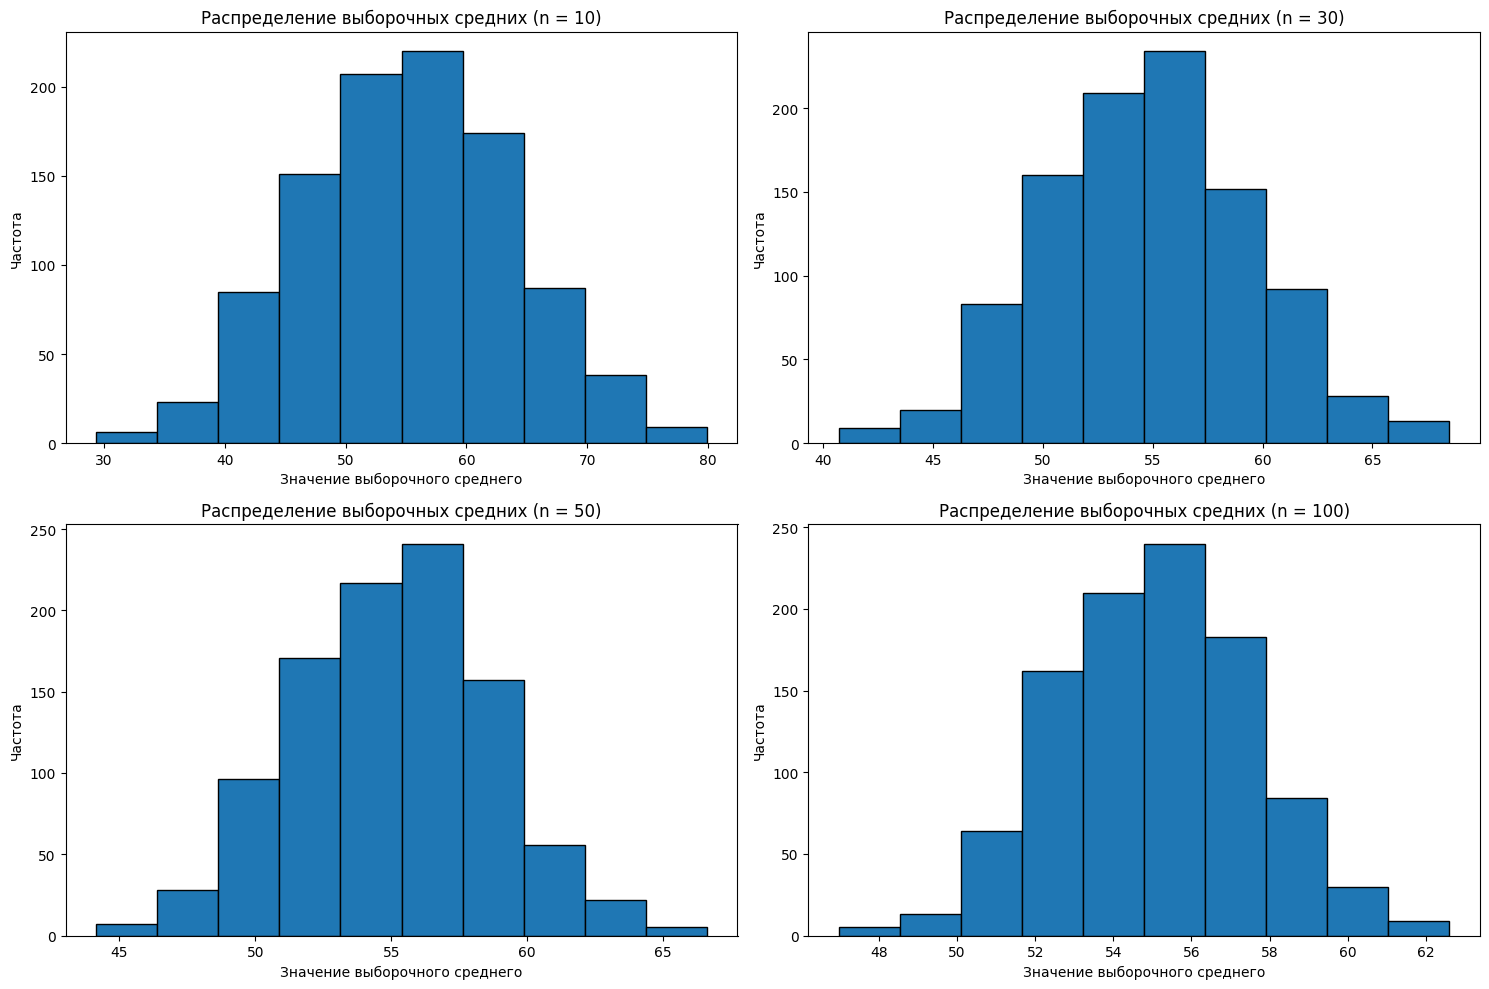

In [32]:
# Параметры моделирования
sample_sizes = [10, 30, 50, 100]
num_samples = 1000

# Одна фигура с сеткой 2x2
figure, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

for i, sample_size in enumerate(sample_sizes):
    hist = generate_sample_means(sample_size = sample_size, num_samples = num_samples)
    axes[i].hist(hist, edgecolor = 'black')
    axes[i].set_title(f'Распределение выборочных средних (n = {sample_size})')
    axes[i].set_xlabel('Значение выборочного среднего')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

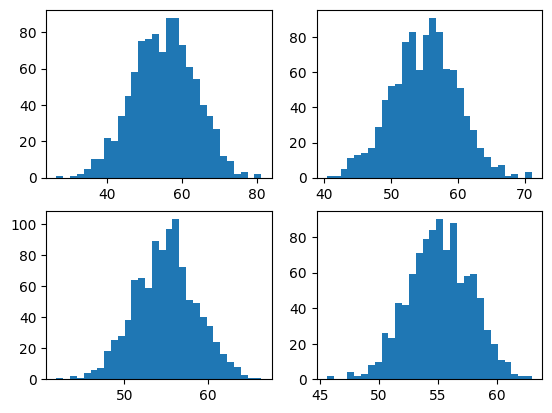

In [33]:
# Параметры для моделирования
hist1 = generate_sample_means(10, 1000)
hist2 = generate_sample_means(30, 1000)
hist3 = generate_sample_means(50, 1000)
hist4 = generate_sample_means(100, 1000)

plt.subplot(2, 2, 1)

plt.hist(hist1, bins=30)

plt.subplot(2, 2, 2)

plt.hist(hist2, bins=30)

plt.subplot(2, 2, 3)

plt.hist(hist3, bins=30)

plt.subplot(2, 2, 4)

plt.hist(hist4, bins=30)

plt.show()

### <b><font color='saddlebrown'>3. Выборочное среднее</font></b>

<b> Задача </b><br>
Компания владеет сайтом, на котором миллионы пользователей ежедневно.

<b> Цель аналитика </b> <br>
Оценить вероятность, что среднее время загрузки для случайной выборки пользователей попадёт в определённый диапазон.

<b>Дано:</b><br>
- Исторические данные показывают, что среднее время загрузки страницы 𝜇 = 4 секунды, стандартное отклонение 𝜎 = 1.2 секунды.
- Выборка: 𝑛 = 50 случайных пользователей.
- Вопрос: какова вероятность, что среднее время загрузки этой выборки будет между 3.8 и 4.2 секунд?

In [35]:
# В переменные mu, sigma, n, lower_limit, upper_limit запишите соответствующие значения
mu = 4
sigma = 1.2
n = 50
lower_limit = 3.8
upper_limit = 4.2

z1 = (lower_limit - mu) / (sigma / np.sqrt(n))
z2 = (upper_limit - mu) / (sigma / np.sqrt(n))

probability = stats.norm.cdf(z2) - stats.norm.cdf(z1)
print(f"Вероятность: {probability*100:.2f}%")


Вероятность: 76.14%


In [36]:
# Шаг 1. Вычислите стандартную ошибку среднего (переменная sem)
sem = sigma / np.sqrt(n)
print(f"Стандартная ошибка среднего: {sem:.4f}")

Стандартная ошибка среднего: 0.1697


In [39]:
# Шаг 2. Вычислите z-score для нижней границы диапазона (переменная z_lower)
z_lower = (lower_limit - mu) / sem
print(f"z-score для нижней границы: {z_lower:.4f}")

z-score для нижней границы: -1.1785


In [40]:
# Шаг 2. Вычислите z-score для верхней границы диапазона (переменная z_upper)
z_upper = (upper_limit - mu) / sem
print(f"z-score для верхней границы: {z_upper:.4f}")

z-score для верхней границы: 1.1785


In [42]:
# Шаг 3. Найдите вероятность через функцию cdf
probability_lower = stats.norm.cdf(z_lower)
probability_upper = stats.norm.cdf(z_upper)

probability_between = probability_upper - probability_lower
print(f"Вероятность того, что выборочное среднее находится в диапазоне от 3.8 до 4.2, \
равна примерно {probability_between*100:.4f}%")

Вероятность того, что выборочное среднее находится в диапазоне от 3.8 до 4.2, равна примерно 76.1407%
